# Laboratoria 10

## Ekstrema warunkowe: tutorial

### Sformułowanie problemu

__Dane:__

1. Funkcja $f\colon U\to \mathbb{R}$, o której zakładamy, że:
>* jest określona na otwartym podzbiorze $U$ przestrzeni $\mathbb{R}^n$;
>* ma ciągłe pochodne cząstkowe rzędu drugiego.
2. Funkcje: $g_1,\ldots,g_m:U\to\mathbb{R}$, o których zakładamy, że:
>* mają ciągłe pochodne cząstkowe rzędu drugiego;
>* rząd macierzy Jacobiego funkcji $g=(g_1,\ldots, g_m)$ jest równy $m$ w dowolnym punkcie zbioru $U$.

__Cel:__

Wyznaczyć ekstrema lokalne funkcji $f$ obciętej do zbioru 
$$\{(x_1,\ldots,x_n)\in U: g_j(x_1,\ldots,x_n)=0 \text{ dla } 1\leq j\leq m\}. $$

__Uwaga:__ ekstrema, o których mowa nazywamy ekstremami warunkowymi.

### Rozwiązanie problemu: metoda mnożników Lagrange'a

__Krok 1.__
Rozważamy funkcję $$F(x_1,\ldots, x_n)=f(x_1,\ldots, x_n)-\sum_{i=1}^m\lambda_ig_i(x_1,\ldots, x_n).$$
>* Funkcja ta zawiera $m$ nieznanych parametrów $\lambda_1,\ldots,\lambda_m$.
>* Funkcję $F$ nazywamy funkcją Lagrange'a.

__Krok 2.__
Rozwiązujemy układ $n+m$ - równań z niewiadomymi $x_1,\ldots,x_n,\lambda_1,\ldots,\lambda_m$: 
$$
\begin{cases}
\frac{\partial F}{\partial x_i}(x_1,\ldots, x_n)=0 &\text{ dla } 1\leq i\leq n\\
g_j(x_1,\ldots,x_n)=0  &\text{ dla } 1\leq j\leq m
\end{cases}
$$

Jego rozwiązaniem są punkty zbioru $U$ wraz z odpowiadającymi im parametrami $\lambda_1,\ldots,\lambda_m$.

__Krok 3.__

Bierzemy dowolny punkt $(a_1,\ldots, a_n)$, który otrzymaliśmy w kroku 2 i odpowiadające mu parametry $\lambda_1,\ldots,\lambda_m$: dla tych parametrów piszemy raz jeszcze funkcję Lagrange'a.

>* Obliczamy $$d^2F(a_1,\ldots,a_n)(h_1,\ldots, h_n)=\sum_{i=1}^n\frac{\partial^2 F}{\partial x_i^2}(a_1,\ldots, a_n)h_i^2+2\sum_{i<j} \frac{\partial^2 F}{\partial x_i\partial x_j}(a_1,\ldots, a_n)h_ih_j.$$
>* Wyznaczamy zbiór:
$$D=\{0\not=(h_1,\ldots,h_n): g_j'(a_1,\ldots,a_n)(h_1,\ldots, h_n)=0,\; j=1,2,...,m\}.$$

__Krok 4.__ Wnioskujemy:
>* Jeśli $d^2F(a_1,\ldots,a_n)(h_1,\ldots, h_n)>0$ dla  $(h_1,\ldots,h_n)\in D$, to $(a_1,\ldots,a_n)$  jest warunkowym minimum lokalnym.
>* Jeśli $d^2F(a_1,\ldots,a_n)(h_1,\ldots, h_n)<0$ dla  $(h_1,\ldots,h_n)\in D$, to $(a_1,\ldots,a_n)$  jest warunkowym maksimum lokalnym.

### Przykład: 

Znajdziemy ekstrema funkcji $f(x,y,z)=xy+yx$ określonej na zbiorze 
$$U=\{(x,y,z):x>0, y>0,z>0 \}$$
przy warunkach 
$$x^2+y^2-2=0\quad \text{i} \quad y+z-2=0.$$

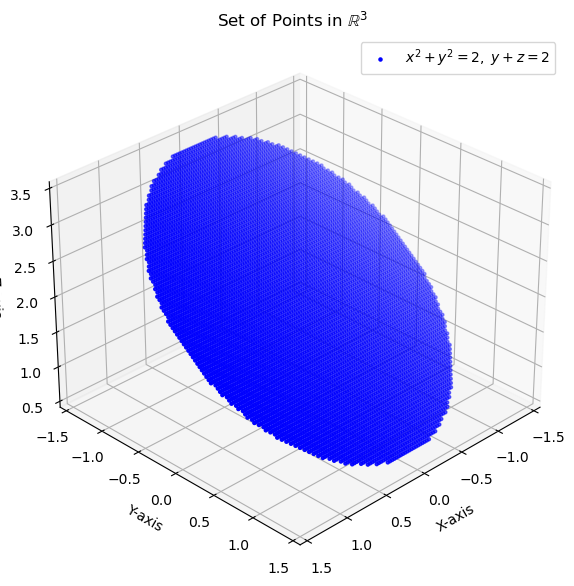

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a range for x and y values
x = np.linspace(-np.sqrt(2), np.sqrt(2), 100)
y = np.linspace(-np.sqrt(2), np.sqrt(2), 100)

# Meshgrid for x and y
X, Y = np.meshgrid(x, y)

# Constraint: x^2 + y^2 = 2
mask = X**2 + Y**2 <= 2

# Calculate Z from the second equation: y + z = 2
Z = 2 - Y

# Apply the mask to satisfy the first equation
X = X[mask]
Y = Y[mask]
Z = Z[mask]

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X, Y, Z, c='blue', s=5, label=r'$x^2 + y^2 = 2, \ y + z = 2$')

# Rotate the plot
ax.view_init(elev=30, azim=45)  # Adjust elevation and azimuth for rotation

# Labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Set of Points in $\mathbb{R}^3$')
ax.legend()

plt.show()


Niech $g_1(x,y,z)=x^2+y^2-2$ i $g_2(x,y,z)=y+z-2$.
Wtedy 
$$
g_1'(x,y,z)(h_1,h_2,h_3)=2xh_1+2yh_2\quad\text{ oraz }\quad g_2'(x,y,z)(h_1,h_2,h_3)=h_2+h_3.
$$
Zatem macierzą Jacobiego funkcji  $g=(g_1, g_2)$
jest macierz 
$$
\begin{bmatrix} 2x & 2y& 0\\
0 & 1 & 1
\end{bmatrix}
$$
której rząd jest równy 2 w dowolnym punkcie zbioru $U$.



__Krok 1.__
Funkcja Lagrange'a to funkcja 
$$
F(x,y,z)=xy+yz-\lambda_1(x^2+y^2-2)-\lambda_2(y+z-2).
$$

__Krok 2.__ Jedynym rozwiązaniem układu równań (w zbiorze $U$)
$$
\begin{cases}
y-2\lambda_1x=0\\
x+y-2\lambda_1y-\lambda_2=0\\
y-\lambda_2=0\\
x^2+y^2=2\\
y+z=2
\end{cases}
$$
jest punkt (1,1,1) i odpowiadające mu paratmetry $\lambda_1=\frac{1}{2}$ oraz $\lambda_2=1$.

__Krok 3.__

__I__ Dla $\lambda_1=\frac{1}{2}$ oraz $\lambda_2=1$
mamy
$$d^2F(1,1,1)(h_1,h_2,h_3)=-h_1^2-h_2^2+2h_1h_2+2h_1h_3.$$
__II__
Wiemy już, że 
$$g_1'(1,1,1)(h_1,h_2,h_3)=2h_1+2h_2\quad\text{ oraz }\quad g_2'(1,1,1)(h_1,h_2,h_3)=h_2+h_3.$$
Zatem

$$
B=\{(0,0,0)\not=(h_1,h_2,h_3:2h_1+2h_2=0\text{ oraz }h_2+h_3=0)\}=\{(t,-t,t):t\not=0\}.
$$

__Krok 4.__ 
Dla $t\not=0$ 

$$
d^2F(1,1,1)(t,-t,t)=-6t^2<0.
$$

Zatem punkt $(1,1,1)$ jest warunkowym maksimum lokalnym.

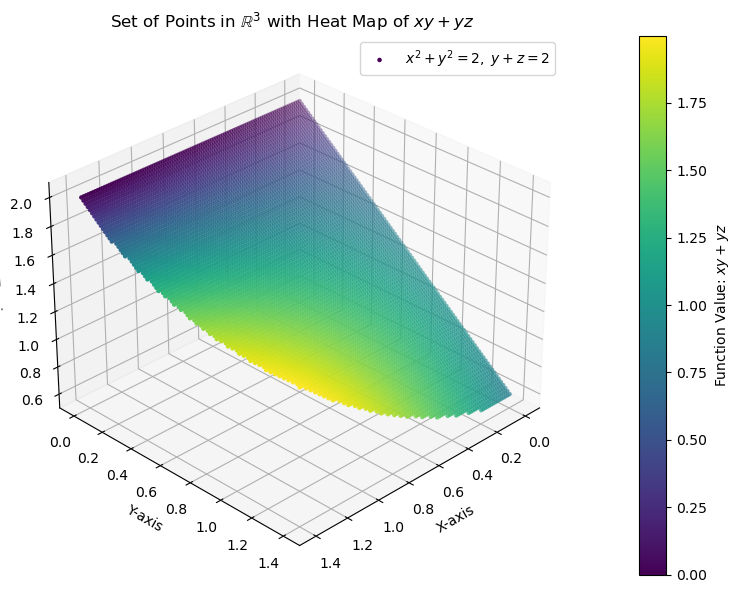

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a range for x and y values
x = np.linspace(0, np.sqrt(2), 100)
y = np.linspace(0, np.sqrt(2), 100)

# Meshgrid for x and y
X, Y = np.meshgrid(x, y)

# Constraint: x^2 + y^2 = 2
mask = X**2 + Y**2 <= 2

# Calculate Z from the second equation: y + z = 2
Z = 2 - Y

# Apply the mask to satisfy the first equation
X = X[mask]
Y = Y[mask]
Z = Z[mask]

# Calculate the values of the function xy + yz
F = X * Y + Y * Z

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the points
sc = ax.scatter(X, Y, Z, c=F, cmap='viridis', s=5, label=r'$x^2 + y^2 = 2, \ y + z = 2$')

# Add color bar for the heat map
cb = plt.colorbar(sc, ax=ax, pad=0.1)
cb.set_label('Function Value: $xy + yz$')

# Rotate the plot
ax.view_init(elev=30, azim=45)  # Adjust elevation and azimuth for rotation

# Labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Set of Points in $\mathbb{R}^3$ with Heat Map of $xy + yz$')
ax.legend()

plt.show()
